# 95 - Linear GAN on Fashion-MNIST

**Section:** GANs | **Prereqs:** `GANs/Linear_GANs_with_MNIST.ipynb` | **Next:** `GANs/CNN_GANs_Guassians.ipynb`

The same fully connected GAN on clothing instead of digits, with both networks
made wider and deeper (512-unit layers rather than 256).

**Why this is harder than MNIST.** Digits are thin strokes on black - most pixels
are background, and the structure is simple. Clothing fills the frame and carries
texture, shading and varied silhouettes. Expect recognisable garment shapes and
blurry texture: a fully connected generator has to learn every pixel's
relationship to every other one independently, with no notion of locality.

**That limitation is the argument for the next notebooks.** A convolutional
generator builds images from local patterns with shared weights, which is why
every modern image GAN is convolutional.

**What to watch for**, in order of likelihood: mode collapse (many samples of the
same garment), the discriminator winning (its loss near zero and the generator
producing noise), and oscillation that never settles.

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchsummary
import sys

In [203]:
fmnist_data = torchvision.datasets.FashionMNIST(root='/', download=True, train=True)

In [204]:
# Min-max scale then map to [-1,1] to match the generator's Tanh output.
# (`2*data - data.max()` works only because data.max() is 1 after the first
# line; `2*data - 1` says it directly.)
data = fmnist_data.data

data = (data - data.min())/(data.max() - data.min())
data = 2*data - data.max()

In [205]:
data.min(), data.max()

(tensor(-1.), tensor(1.))

In [206]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [207]:
# Flatten to 784 and move to the GPU.
data = data.float().to(device).view(data.shape[0],784)
type(data), data.dtype

(torch.Tensor, torch.float32)

In [208]:
data[0].shape

torch.Size([784])

In [209]:
batchsize = 100

In [210]:
# The discriminator, wider and deeper than the MNIST version:
# 784 -> 512 -> 512 -> 256 -> 1. Fashion-MNIST has more structure to judge.
class discriminator(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.fc1 = nn.Linear(28*28,512)
    self.fc2 = nn.Linear(512,512)
    self.fc3 = nn.Linear(512,256)
    self.out = nn.Linear(256,1)

  def forward(self,x):
    x = F.leaky_relu(self.fc1(x))
    x = F.leaky_relu(self.fc2(x))
    x = F.leaky_relu(self.fc3(x))

    return torch.sigmoid(self.out(x))

In [211]:
dnet = discriminator().to(device)
dnet

discriminator(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
)

In [212]:
torchsummary.summary(dnet,(784,), batch_size=batchsize)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 512]         401,920
            Linear-2                 [100, 512]         262,656
            Linear-3                 [100, 256]         131,328
            Linear-4                   [100, 1]             257
Total params: 796,161
Trainable params: 796,161
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 0.98
Params size (MB): 3.04
Estimated Total Size (MB): 4.31
----------------------------------------------------------------


In [213]:
# The generator: 64 -> 256 -> 512 -> 784 -> 784, Tanh out.
# Note the extra 784 -> 784 layer at full image width - unusual, and a lot of
# parameters (614k) for what is essentially a final refinement pass.
class generator(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.fc1 = nn.Linear(64,256)
    self.fc2 = nn.Linear(256,512)
    self.fc3 = nn.Linear(512,784)
    self.out = nn.Linear(784,784)

  def forward(self,x):

    x = F.leaky_relu(self.fc1(x))
    x = F.leaky_relu(self.fc2(x))
    x = F.leaky_relu(self.fc3(x))

    return F.tanh(self.out(x))

In [214]:
gnet = generator().to(device)
gnet

generator(
  (fc1): Linear(in_features=64, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=784, bias=True)
  (out): Linear(in_features=784, out_features=784, bias=True)
)

In [215]:
torchsummary.summary(gnet, (64,),batchsize)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 256]          16,640
            Linear-2                 [100, 512]         131,584
            Linear-3                 [100, 784]         402,192
            Linear-4                 [100, 784]         615,440
Total params: 1,165,856
Trainable params: 1,165,856
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 1.78
Params size (MB): 4.45
Estimated Total Size (MB): 6.25
----------------------------------------------------------------


### Now we train

In [216]:
# Two optimizers at lr=5e-4. Higher than the MNIST notebook, which speeds
# training and makes instability more likely - a trade worth knowing you made.
epochs =  50000

lossfunc = nn.BCELoss()

g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0005)
d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0005)

In [217]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
losses = torch.zeros((epochs,2))
dnet_decisions = torch.zeros((epochs,2))

for epoch in range(epochs):

  # Make random mini batches
  randidx = torch.randint(data.shape[0],(batchsize,))
  real_images = data[randidx,:]
  fake_images = gnet(torch.randn(batchsize,64).to(device))

  # Adding Labels
  real_labels = torch.ones((batchsize,1)).to(device)
  fake_labels  = torch.zeros((batchsize,1)).to(device)

  # Training the discriminator

  preds_real = dnet(real_images)
  d_loss_real = lossfunc(preds_real,real_labels)

  preds_fake = dnet(fake_images)
  d_loss_fake = lossfunc(preds_fake,fake_labels)

  d_loss = d_loss_real + d_loss_fake
  losses[epoch,0] = d_loss.item()
  dnet_decisions[epoch,0] = torch.mean((preds_real > 0.5).float()).detach() # Checking how is dnet performing on real data

  d_optimizer.zero_grad()
  d_loss.backward()
  d_optimizer.step()


  # Training the generator

  fake_images = gnet(torch.randn(batchsize,64).to(device))
  preds_fake = dnet(fake_images)

  g_loss = lossfunc(preds_fake, real_labels) # Compare with real labels, to push the model to learn
  losses[epoch,1] = g_loss.item()
  dnet_decisions[epoch,1] = torch.mean((preds_fake > 0.5).float()).item() # Checking how is dnet performing on fake data

  g_optimizer.zero_grad()
  g_loss.backward()
  g_optimizer.step()


  if (epoch+1) % 500 == 0:
    msg = f'Epoch {epoch+1}/{epochs}'
    sys.stdout.write('\r' + msg)
    sys.stdout.flush()

Epoch 50000/50000

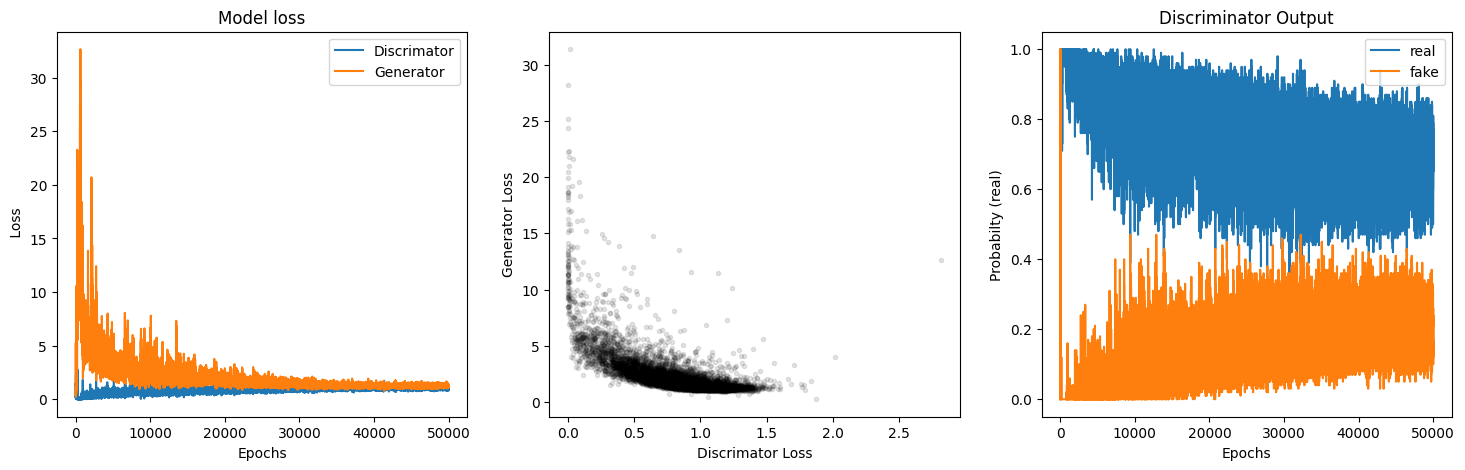

In [224]:
# The three GAN diagnostics:
# LEFT   - both losses over time. Look for sustained oscillation, not
#          convergence. A GAN that 'converges' has usually collapsed.
# MIDDLE - discriminator loss against generator loss. A diagonal cloud means the
#          two are trading blows; a point in one corner means one has won.
# RIGHT  - the discriminator's decisions on real and fake. At equilibrium both
#          approach 0.5: it can no longer tell them apart. That is the target,
#          and it is the closest thing a GAN has to an accuracy metric.
fig,ax = plt.subplots(1,3, figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel(' Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator', 'Generator'])
#ax[0].set_xlim([3000,4000])

ax[1].plot(losses [::5,0], losses [::5,1], 'k.',alpha=.1)
ax[1].set_xlabel('Discrimator Loss')
ax[1].set_ylabel('Generator Loss')

ax[2].plot(dnet_decisions)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probabilty (real)')
ax[2].set_title('Discriminator Output')
ax[2].legend(['real', 'fake']);


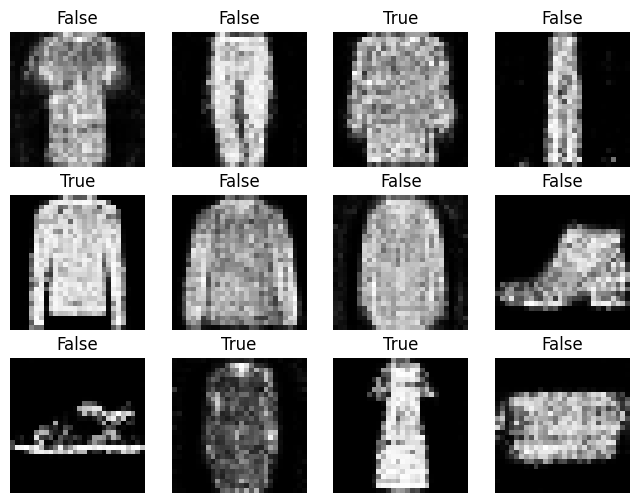

In [221]:
# Generated garments. Expect recognisable silhouettes - trousers, shirts, shoes -
# with blurry texture. The blur is the fully connected generator's limitation:
# it has no notion of locality and must learn every pixel relationship
# independently. That is exactly what convolution fixes.
# Now we generate fake data, we start with pure random noise.

gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()
fake_pred = dnet(fake_data.to(device))

# and visualize...
fig, axs = plt.subplots(3,4, figsize=(8,6))

for i, ax in enumerate(axs.flatten()):
  ax.imshow (fake_data[i,:,].detach().view(28,28), cmap='gray')
  ax.set_title((fake_pred[i] > 0.5).item())
  ax.axis('off')

plt.show()